# First RL Implementation


## 1 Task

Agent needs to manage portfolio of asset (e.g. stock) and cash by changing allocations. 
Goal is to maximize portfolio value at end of episode t=100.
Initial allocation is 50/50 of 100 USD budget.


## 2 Markov Decision Process

- State: price change (up or down)
- Action: changing allocation by +- 10% or stay (3 actions)
- Reward: return of asset multiplied by allocation

## 3 RL Model

- tabular Q-learning with 2 states and 3 actions, so 6 Q-values

## 4 Market Simulation

- start with normal distribution

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# define price series generator
def normal_price(mu, sigma):
    price = np.random.normal(mu, sigma, 1)
    return price


normal_price(100, 1)

In [110]:
for i in range(10):
    print(normal_price(100, 1))

99.71467975253569
101.37030586993697
100.18246239140059
100.53999767191198
99.92376633125754
100.60775818168246
100.32826387110718
100.80780955451065
100.7301197654387
99.64074073350012


In [111]:
# define agent, with actions -1,0,1 for sell, hold, buy

def baseline_agent(state):
    return 0


class BaselineAgent:
    def __init__(self):
        self.state = 0

    def act(self, state):
        return 0

    def learn(self, state, action, reward, next_state):
        pass

In [83]:
import numpy as np

class QLearningAgent:
    def __init__(self, alpha, gamma, epsilon, num_states, num_actions):
        self.alpha = alpha      # Learning rate
        self.gamma = gamma      # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.num_states = num_states
        self.num_actions = num_actions
        
        # Q-table initialized with zeros
        self.q = np.zeros((num_states, num_actions))

    def act(self, state):
        """ Choose action based on epsilon-greedy policy """
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_actions)  # Explore
        else:
            return np.argmax(self.q[state])  # Exploit best known action

    def learn(self, state, action, reward, next_state):
        """ Update Q-table based on reward and next state """
        best_next_action = np.argmax(self.q[next_state])  # Best action in the next state
        td_target = reward + self.gamma * self.q[next_state, best_next_action]  # TD target
        td_error = td_target - self.q[state, action]  # Temporal Difference error
        
        # Update Q-value
        self.q[state, action] += self.alpha * td_error


In [84]:
# define environment, state 0, 1 for price decrease, increase

start_price = 10
mu = 10
sigma = 1
current_price = start_price
initial_cash = 500
initial_stock_value= 500


q_agent = QLearningAgent(alpha=0.1, gamma=0.9, epsilon=0.1, num_states=2, num_actions=3)

def environment(n, mu, sigma, initial_cash, initial_stock_value, start_price):



    pvs = np.zeros(n)
    allocations = np.zeros(n)
    prices = np.zeros(n)
    stock_values = np.zeros(n)
    cashs = np.zeros(n)
    actions = np.zeros(n)
    rewards = np.zeros(n) 



    stock_values[0] = initial_stock_value
    cashs[0] = initial_cash
    allocations[0] = initial_stock_value/(initial_stock_value + initial_cash)
    pvs[0] = initial_stock_value + initial_cash
    prices[0] = start_price

    for i in range(1,n):


        

        # step 1: price change
        price = normal_price(mu, sigma)
        prices[i] = price
        return_ratio = price/prices[i-1]
        

        # step 2: adjust portfolio based on price change
        stock_values[i] = stock_values[i-1] * return_ratio
        cashs[i] = cashs[i-1]
        pvs[i] = cashs[i] + stock_values[i]
        allocations[i] = stock_values[i]/pvs[i]

        
        # step 3: decide action
        # get state
        if return_ratio > 1:
            state = 1
        else:
            state = 0

        # get action based on state
        action = q_agent.act(state)
        actions[i] = action

        # get target allocation based on action
        if action == 0 and allocations[i] < 0.9:
            target_allocation = allocations[i] + 0.1
        elif action == 1 and allocations[i] > 0.1:
            target_allocation = allocations[i] - 0.1
        else:
            target_allocation = allocations[i]

        # step 4: adjust portfolio based on action 
        stock_values[i] = pvs[i] * target_allocation
        cashs[i] = pvs[i] - stock_values[i]
        allocations[i] = stock_values[i]/pvs[i]

        # step 5: calculate reward and feed back to agent
        reward = pvs[i] - pvs[i-1]
        rewards[i] = reward
        next_state = state # assume that next state is current state
        q_agent.learn(state, action, reward, next_state)

    return pvs, allocations, prices, stock_values, cashs, rewards






        

        
        




In [94]:
# run environment with 100 steps
pvs, allocations, prices, stock_values, cashs, rewards = environment(10000, mu, sigma, initial_cash, initial_stock_value, start_price)

In [107]:
q_agent.q

array([[-0.08860379, -0.02342098, -0.09116922],
       [ 0.06859007,  0.06838355,  0.06912627]])

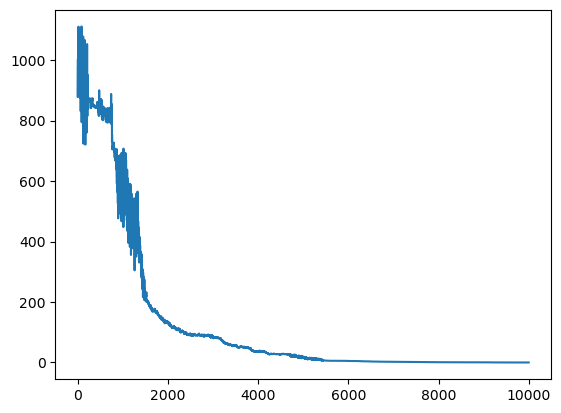

In [95]:
plt.plot(pvs)

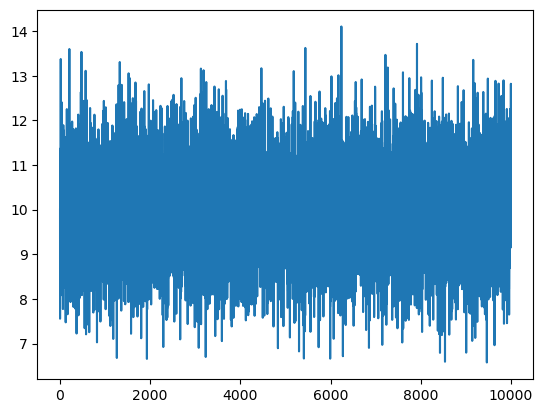

In [96]:
plt.plot(prices)

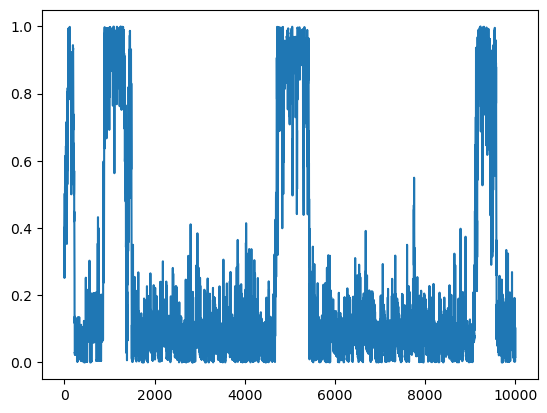

In [97]:
plt.plot(allocations)

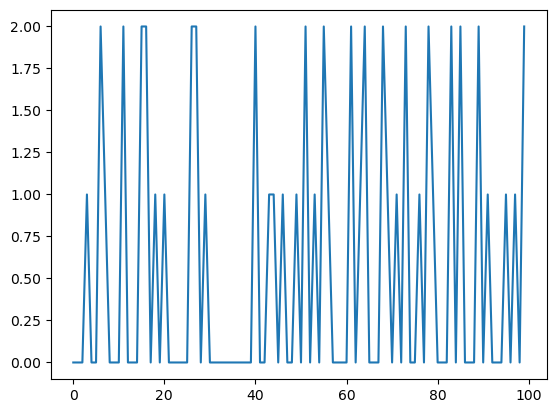

In [98]:
plt.plot(actions)

(array([63.,  0.,  0.,  0.,  0., 19.,  0.,  0.,  0., 18.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

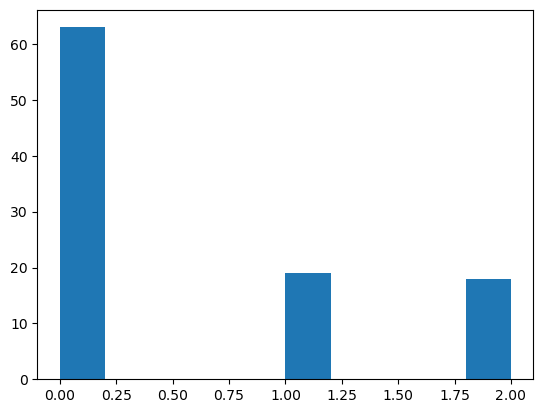

In [100]:
plt.hist(actions)

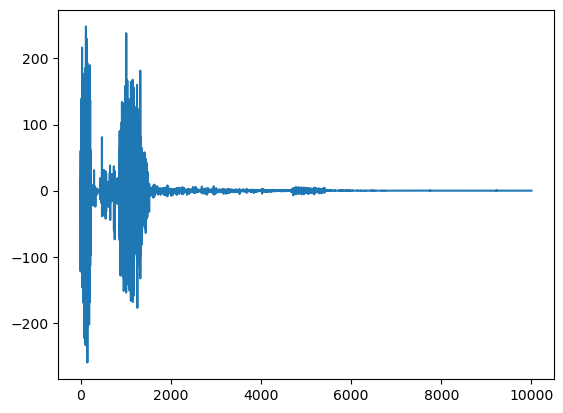

In [99]:
plt.plot(rewards)

-0.09999493071905072

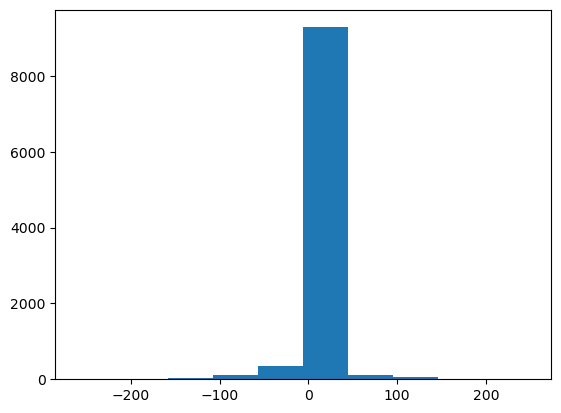

In [106]:
plt.hist(rewards);
rewards.mean()

price, Cash, Stock value, Budget, allocation, action
10, 500, 500, 1000, 0.5, 1
11, 500, 550, 1050, 0.6, -1
12, 500, 600, 1100, 0.7, 1

t = 0
price changes from 9 to 10
10, 500, 500, 1000, 0.5, 
action 0 by default or random leading to change in allocation
10, 500, 500, 1000, 0.5
t=1
price change from 10 to 11
11, 500, 550, 1050, resulting in new pv
action = -1, adjusitng portfolio allocation by -10
11, 605, 445, 1050, 0.64
t=2
price change from 11 to 12
12, 605, 


In [46]:
# define environment, state 0, 1 for price decrease, increase

n = 100
start_price = 10
mu = 10
sigma = 1
current_price = start_price
initial_cash = 500
initial_stock_value= 500
pvs = np.zeros(n)
allocations = np.zeros(n)
prices = np.zeros(n)
stock_values = np.zeros(n)
cashs = np.zeros(n)

rewards = np.zeros(n) 

def environment(n, mu, sigma, initial_cash, initial_stock_value, start_price):

    stock_values[0] = initial_stock_value
    cashs[0] = initial_cash
    allocations[0] = initial_stock_value/(initial_stock_value + initial_cash)
    pvs[0] = initial_stock_value + initial_cash
    prices[0] = start_price

    for i in range(1,n):


        

        # step 1: price change
        price = normal_price(mu, sigma)[0]
        prices[i] = price
        return_ratio = price/prices[i-1]
        

        # step 2: adjust portfolio based on price change
        stock_values[i] = stock_values[i-1] * return_ratio
        cashs[i] = cashs[i-1]
        pvs[i] = cashs[i] + stock_values[i]
        allocations[i] = stock_values[i]/pvs[i]

        
        # step 3: decide action
        # get state
        if return_ratio > 1:
            state = 1
        else:
            state = 0

        # get action based on state
        action = baseline_agent(state)

        # get target allocation based on action
        if action == 1 and allocations[i] < 1:
            target_allocation = allocations[i] + 0.1
        elif action == -1 and allocations[i] > 0:
            target_allocation = allocations[i] - 0.1
        else:
            target_allocation = allocations[i]

        # step 4: adjust portfolio based on action 
        stock_values[i] = pvs[i] * target_allocation
        cashs[i] = pvs[i] - stock_values[i]
        allocations[i] = stock_values[i]/pvs[i]

        # step 5: calculate reward and next state and feed back to agent
        reward = pvs[i] - pvs[i-1]
        rewards[i] = reward



    return pvs, allocations, prices, stock_values, cashs, rewards






        

        
        




In [47]:
# run environment with n =100
pvs, allocations, prices, stock_values, cashs, rewards = environment(n, mu, sigma, initial_cash, initial_stock_value, start_price)

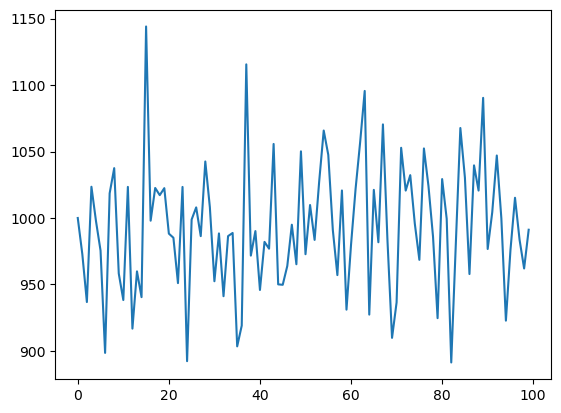

In [48]:
# plot price and portfolio value
import matplotlib.pyplot as plt

plt.plot(pvs)
plt.show()

In [49]:
pvs

array([1000.        ,  972.73975465,  936.75373014, 1023.49658952,
        997.6666733 ,  975.44756287,  898.4843181 , 1018.56486642,
       1037.49786612,  958.25005297,  938.26377049, 1023.38781759,
        916.75008349,  959.82967629,  940.43083711, 1144.0943943 ,
        997.96008265, 1022.57475553, 1017.18299358, 1022.44486004,
        988.23821375,  985.1156395 ,  950.99540594, 1023.36422492,
        892.2537948 ,  998.83516447, 1007.96950092,  986.34688546,
       1042.51464863, 1008.20336294,  952.39808601,  988.38548296,
        941.14074523,  986.36516198,  988.72765829,  903.40139062,
        919.01424796, 1115.58301101,  971.6929057 ,  990.14369363,
        945.8363641 ,  982.01399853,  976.89467861, 1055.69681508,
        950.05268814,  949.73179588,  963.86701636,  994.93001454,
        965.18985344, 1050.14557615,  972.73803868, 1009.7513018 ,
        983.50948319, 1027.29501953, 1065.79750205, 1047.51533412,
        990.95941337,  957.02264142, 1020.70618405,  931.02130

In [50]:
prices

array([10.        ,  9.45479509,  8.7350746 , 10.46993179,  9.95333347,
        9.50895126,  7.96968636, 10.37129733, 10.74995732,  9.16500106,
        8.76527541, 10.46775635,  8.33500167,  9.19659353,  8.80861674,
       12.88188789,  9.95920165, 10.45149511, 10.34365987, 10.4488972 ,
        9.76476428,  9.70231279,  9.01990812, 10.4672845 ,  7.8450759 ,
        9.97670329, 10.15939002,  9.72693771, 10.85029297, 10.16406726,
        9.04796172,  9.76770966,  8.8228149 ,  9.72730324,  9.77455317,
        8.06802781,  8.38028496, 12.31166022,  9.43385811,  9.80287387,
        8.91672728,  9.64027997,  9.53789357, 11.1139363 ,  9.00105376,
        8.99463592,  9.27734033,  9.89860029,  9.30379707, 11.00291152,
        9.45476077, 10.19502604,  9.67018966, 10.54590039, 11.31595004,
       10.95030668,  9.81918827,  9.14045283, 10.41412368,  8.62042619,
        9.59999006, 10.44071166, 11.14251097, 11.91182927,  8.54595988,
       10.4231665 ,  9.63473909, 11.40834199,  9.657293  ,  8.19

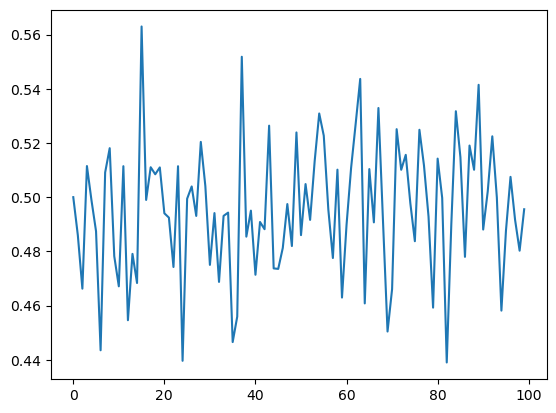

In [51]:
# plot allocatoins
plt.plot(allocations)

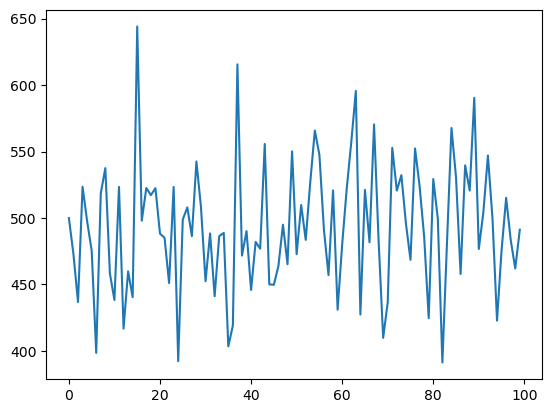

In [52]:
# plot stock values
plt.plot(stock_values)

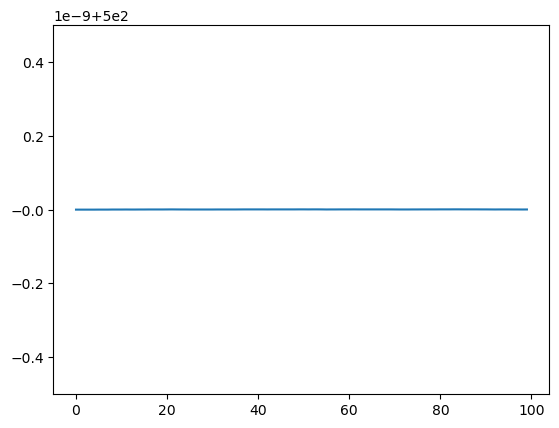

In [53]:
# plot cahs
plt.plot(cashs)

In [55]:
cashs

array([500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500.])

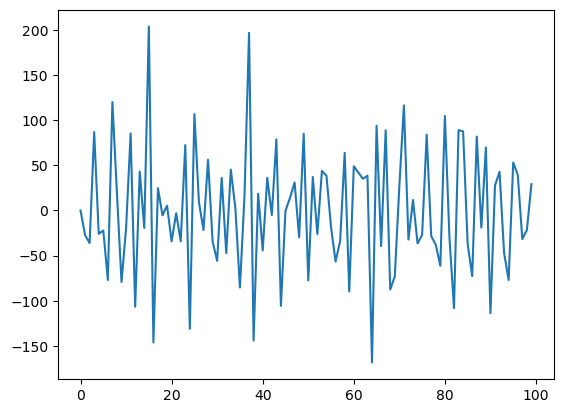

In [54]:
# plot rewards
plt.plot(rewards)